# jaxfne — Étude No. 6 · Multi-Area Network — Connecting Columns

Connect several canonical columns into a multi-area cortical hierarchy
(V1 → V2 → V4 → PFC) and wire **inter-areal feedforward + feedback** on top of
each column's intra-laminar connectivity.

- **Feedforward** lo → hi: superficial L2/3 excitatory → granular L4.
- **Feedback** hi → lo: deep L6 → L1/L5.

Built entirely from the package API (`build_multi_area_columns` with the canonical
E:I profile + the built-in Izhikevich emitter). jaxfne is the mathematical
backend; the biophysical detail follows the configuration. Readouts are `*_proxy`
scaffolds.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jaxfne as jtfne
print("jaxfne", jtfne.__version__)

jaxfne 0.4.3


## 1 · Config — editable parameters (the knobs)

In [2]:
AREAS = ["V1", "V2", "V4", "PFC"]   # ordered low -> high in the hierarchy
N_PER_AREA = 150
DURATION_MS, DT_MS, SEED = 1500.0, 0.5, 0
P_FF, P_FB, WITHIN_GAIN = 0.30, 0.20, 0.40   # inter-areal feedforward / feedback / within-gain
print(f"{len(AREAS)} areas x {N_PER_AREA} neurons = {len(AREAS) * N_PER_AREA}")

4 areas x 150 neurons = 600


## 2 · Build the multi-area network (canonical biophysics per column)

In [3]:
cfg = (
    jtfne.build_multi_area_columns(
        AREAS, n_per_area=N_PER_AREA, ei_profile="canonical",
        connectivity_mode="sparse", p_feedforward=P_FF, p_feedback=P_FB,
        within_gain=WITHIN_GAIN)
    .runtime(seed=SEED)
    .set_emitter("izhikevich", "cortical_eig")
    .probes(["spikes", "V_m", "LFP", "CSD"], n_contacts=16)
    .field(domain="laminar_column", conductivity="proxy", boundary="mean_zero_neumann")
)
model = jtfne.construct(cfg)
nt = model.neuron_table()
area = np.array([r["area"] for r in nt]); layer = np.array([r["layer"] for r in nt])
N = len(nt)
print(f"built {N} neurons across {len(AREAS)} areas")

built 600 neurons across 4 areas


## 3 · Inter-areal connectivity census — feedforward + feedback

Confirm the hierarchy is wired in both directions with the right anatomical
routing (FF: L2/3 → L4; FB: L6 → L1/L5).

In [4]:
el = model.params["edge_list"]; pre = np.asarray(el.pre); post = np.asarray(el.post)
rank = {a: i for i, a in enumerate(AREAS)}
inter = area[pre] != area[post]
rpre = np.array([rank[a] for a in area[pre]]); rpost = np.array([rank[a] for a in area[post]])
ff = inter & (rpre < rpost); fb = inter & (rpre > rpost)
print(f"feedforward (lo->hi): {int(ff.sum())} edges  {sorted(set(layer[pre[ff]]))} -> {sorted(set(layer[post[ff]]))}")
print(f"feedback    (hi->lo): {int(fb.sum())} edges  {sorted(set(layer[pre[fb]]))} -> {sorted(set(layer[post[fb]]))}")

feedforward (lo->hi): 419 edges  [np.str_('L2/3')] -> [np.str_('L4')]
feedback    (hi->lo): 1048 edges  [np.str_('L6')] -> [np.str_('L1'), np.str_('L5')]


## 4 · Interactive 3D layout (Plotly → HTML)

In [5]:
from pathlib import Path
assets = Path("assets"); assets.mkdir(exist_ok=True)
fig3d = jtfne.vis.visualize_network_3d(
    nt, title=f"Étude 6 — {N}-neuron multi-area network",
    show_layers=True, show_edges=False,
    output_html=str(assets / "etude6_network_3d.html"))
print("interactive 3D layout saved -> assets/etude6_network_3d.html")
fig3d

interactive 3D layout saved -> assets/etude6_network_3d.html


## 5 · Simulate + per-area depth-ordered raster

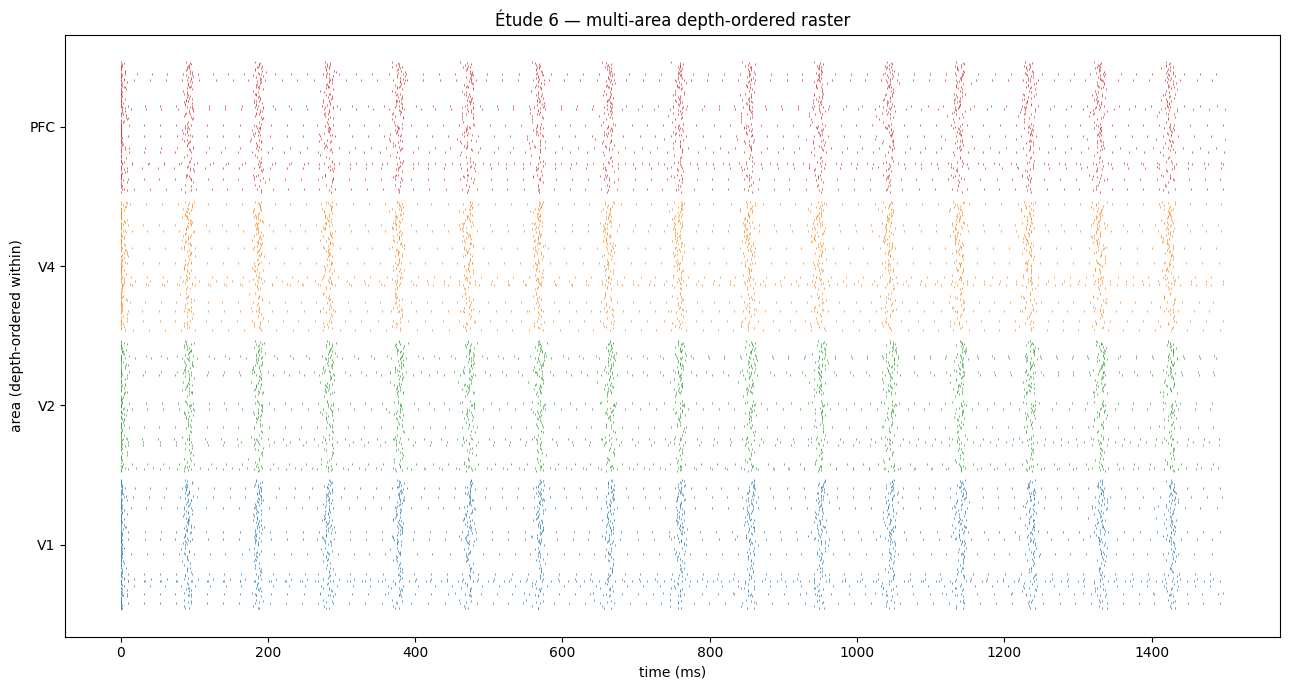

In [6]:
sig = jtfne.simulate(model, sim=jtfne.Simulation(
    duration_ms=DURATION_MS, dt_ms=DT_MS, seed=SEED,
    runtime=jtfne.RuntimeConfig(recurrent_backend="edge_list")))
Z = np.array([r["z"] for r in nt])
cmap = {"V1": "#1f77b4", "V2": "#2ca02c", "V4": "#ff7f0e", "PFC": "#d62728"}
fig, ax = plt.subplots(figsize=(13, 7)); yoff = 0; ticks = []
for a in AREAS:
    idx = np.where(area == a)[0]; order = idx[np.argsort(Z[idx])]
    rmap = {n: yoff + i for i, n in enumerate(order)}
    ti, ni = np.nonzero(sig.spikes[:, idx]); gni = idx[ni]
    ax.scatter(ti * DT_MS, [rmap[n] for n in gni], s=1.5, c=cmap[a], marker="|", linewidths=0.5)
    ticks.append((yoff + len(idx) / 2, a)); yoff += len(idx) + 10
ax.set_yticks([p for p, _ in ticks]); ax.set_yticklabels([a for _, a in ticks])
ax.set_xlabel("time (ms)"); ax.set_ylabel("area (depth-ordered within)")
ax.set_title("Étude 6 — multi-area depth-ordered raster")
plt.tight_layout(); plt.savefig(assets / "etude6_raster.png", dpi=120, bbox_inches="tight"); plt.show()

## 6 · Objective — async-irregular hierarchy gate

Each area should stay asynchronous-irregular (synchrony κ low) at a comparable
firing rate; a global rhythm (κ ≳ 0.2) would make laminar/areal readouts
untrustworthy.

In [7]:
rows = []
for a in AREAS:
    sp = sig.spikes[:, np.where(area == a)[0]]
    rate = float(np.asarray(sp).sum() / sp.shape[1] / (DURATION_MS / 1000.0))
    rows.append((a, rate, float(jtfne.kappa_synchrony(sp, DT_MS))))
max_kappa = max(k for _, _, k in rows)
for a, rate, k in rows:
    print(f"{a:5} rate={rate:5.1f} Hz   kappa={k:.3f}")
print(f"async-irregular gate (all kappa < 0.2): {'PASS' if max_kappa < 0.2 else 'FAIL'} (max={max_kappa:.3f})")

V1    rate= 11.6 Hz   kappa=0.036
V2    rate= 11.6 Hz   kappa=0.033
V4    rate= 11.6 Hz   kappa=0.030
PFC   rate= 11.6 Hz   kappa=0.032
async-irregular gate (all kappa < 0.2): PASS (max=0.036)


## 7 · Export — manifest + figure artifacts

In [8]:
man = jtfne.manifest(cfg, signals=sig)
print("manifest config_hash:", man.get("config_hash"))
print("saved figures:", [p.name for p in sorted(assets.glob("etude6_*"))])

manifest config_hash: 439fa9f27f3b9103
saved figures: ['etude6_network_3d.html', 'etude6_raster.png']


## Notes

- The hierarchy is wired by `build_multi_area_columns`: feedforward L2/3 → L4 (lo → hi)
  and feedback L6 → L1/L5 (hi → lo) for every adjacent pair, with inter-areal weights
  sparser than within-column connectivity.
- Computational scaffold; `*_proxy` readouts only. jaxfne is the mathematical backend —
  biophysical fidelity follows the configuration you provide.